# Project Name -Financial Forecasting Frontier: Distributed ML

Project Type - Distributed Machine Learning
Contribution - Individual

# Project Summary -

Part 1 — Data Analysis and Management.


Part 2 — Exploratory Data Analysis with Spark.

Part 3 — Predictive Modelling with Spark MLlib.

*  Logistic Regression — fast baseline, good interpretability.
*  Random Forest — better accuracy and handles class imbalance more gracefully.

Part 4 — Real-Time Stream Processing.

Part 5 — Data Parallelism.

Install PySpark

# Github_Link

https://github.com/Kashfur/Financial-Forecasting-Frontier-Distributed-ML

# Problem Statement

Banks deal with large volumes of customer data daily. This project simulates how a bank's data engineering team would use distributed computing to process, analyse, and extract predictions from customer marketing data all without needing a physical cluster, by running Spark in local mode on Google Colab.

Data Overview
* age: Age of the individual (integer).
* job: Job type (object/string).
* marital: Marital status (object/string).
* education: Education level (object/string).
* default: Indicates if the individual has credit in default (object/string).
* balance: Account balance (integer).
* housing: Indicates if the individual has a housing loan (object/string).
* loan: Indicates if the individual has a personal loan (object/string).
* contact: Type of communication contact (object/string).
* day: Last contact day of the month (integer).
* month: Last contact month of the year (object/string).
* duration: Last contact duration, in seconds (integer).
* campaign: Number of contacts performed during this campaign for this client (integer).
* pdays: Number of days that passed by after the client was last contacted from a previous campaign (integer, '-1' means client was not previously contacted).
* previous: Number of contacts performed before this campaign and for this client (integer).
* poutcome: Outcome of the previous marketing campaign (object/string).
* y: Indicates if the client has subscribed to a term deposit (object/string).

# Let's Begin !

In [ ]:
!pip install pyspark -q

# Hive queries

1. Know Your Data

Load data:

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Assignment_doc/distributed-banking-ml/data/bank.csv")
print(f"Rows: {len(df)}  Columns: {len(df.columns)}")
df.head()

Rows: 4521  Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Install and use pandasql

In [ ]:
!pip install pandasql -q
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

Query 1: Subscription rate:

In [ ]:
q1 = pysqldf("""
    SELECT y as subscribed,
           COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM df), 2) as pct
    FROM df
    GROUP BY y
""")
print(q1)

  subscribed  count    pct
0         no   4000  88.48
1        yes    521  11.52


Query 2: Subscription rate by job:

In [ ]:
q2 = pysqldf("""
    SELECT job,
           COUNT(*) as total,
           SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) as subscribed,
           ROUND(SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as rate_pct
    FROM df
    GROUP BY job
    ORDER BY rate_pct DESC
""")
print(q2)

              job  total  subscribed  rate_pct
0         retired    230          54     23.48
1         student     84          19     22.62
2         unknown     38           7     18.42
3      management    969         131     13.52
4       housemaid    112          14     12.50
5          admin.    478          58     12.13
6   self-employed    183          20     10.93
7      technician    768          83     10.81
8      unemployed    128          13     10.16
9        services    417          38      9.11
10   entrepreneur    168          15      8.93
11    blue-collar    946          69      7.29


Query 3: Average balance and duration by outcome:

In [ ]:
q3 = pysqldf("""
    SELECT y,
           ROUND(AVG(balance),2) as avg_balance,
           ROUND(AVG(duration),2) as avg_duration_sec,
           ROUND(AVG(age),1) as avg_age
    FROM df
    GROUP BY y
""")
print(q3)

     y  avg_balance  avg_duration_sec  avg_age
0   no      1403.21            226.35     41.0
1  yes      1571.96            552.74     42.5


Query 4: Best converting education level:

In [ ]:
q4 = pysqldf("""
    SELECT education,
           COUNT(*) as total,
           SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) as yes_count,
           ROUND(SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as conversion_pct
    FROM df
    GROUP BY education
    ORDER BY conversion_pct DESC
""")
print(q4)

   education  total  yes_count  conversion_pct
0   tertiary   1350        193           14.30
1  secondary   2306        245           10.62
2    unknown    187         19           10.16
3    primary    678         64            9.44


Query 5: Month-wise campaign results:

In [ ]:
q5 = pysqldf("""
    SELECT month,
           COUNT(*) as contacts,
           SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) as subscriptions,
           ROUND(SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as success_rate
    FROM df
    GROUP BY month
    ORDER BY contacts DESC
""")
print(q5)

   month  contacts  subscriptions  success_rate
0    may      1398             93          6.65
1    jul       706             61          8.64
2    aug       633             79         12.48
3    jun       531             55         10.36
4    nov       389             39         10.03
5    apr       293             56         19.11
6    feb       222             38         17.12
7    jan       148             16         10.81
8    oct        80             37         46.25
9    sep        52             17         32.69
10   mar        49             21         42.86
11   dec        20              9         45.00


# Part 2 — EDA with Spark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("BankEDA") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark started:", spark.version)

Spark started: 4.0.2


 Load data into Spark:

In [ ]:
df_spark = spark.read.csv('/content/drive/MyDrive/Assignment_doc/distributed-banking-ml/data/bank.csv', header=True, inferSchema=True)
print(f"Rows: {df_spark.count()}  Columns: {len(df_spark.columns)}")
df_spark.printSchema()

Rows: 4521  Columns: 17
root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



Null check:

In [ ]:
null_counts = df_spark.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_spark.columns
])
null_counts.show()

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



Class balance:

In [ ]:
df_spark.groupBy("y").count() \
    .withColumn("pct", F.round(F.col("count")*100/df_spark.count(), 2)) \
    .show()

+---+-----+-----+
|  y|count|  pct|
+---+-----+-----+
| no| 4000|88.48|
|yes|  521|11.52|
+---+-----+-----+



 Descriptive stats:

In [ ]:
num_cols = ["age","balance","duration","campaign","pdays","previous"]
df_spark.select(num_cols).describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|               age|           balance|          duration|          campaign|             pdays|          previous|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|              4521|              4521|              4521|              4521|              4521|              4521|
|   mean| 41.17009511170095|1422.6578190665782|263.96129174961294| 2.793629727936297|39.766644547666445|0.5425790754257908|
| stddev|10.576210958711263|3009.6381424673395|259.85663262468216|3.1098066601885823|100.12112444301656|1.6935623506071211|
|    min|                19|             -3313|                 4|                 1|                -1|                 0|
|    max|                87|             71188|              3025|                50|               871|                25|
+-------

Correlation heatmap:

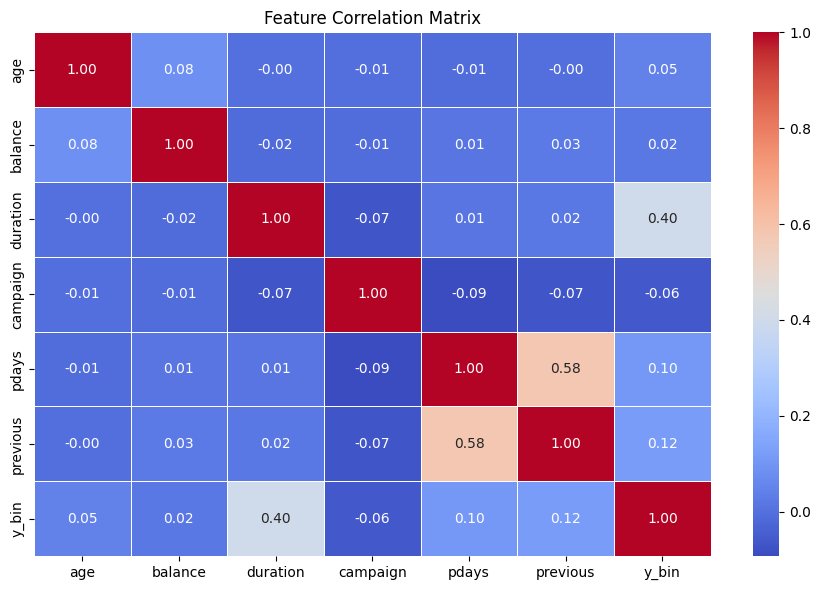

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pdf = df_spark.select(num_cols + ["y"]).toPandas()
pdf["y_bin"] = (pdf["y"] == "yes").astype(int)

corr = pdf[num_cols + ["y_bin"]].corr()

plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=120)
plt.show()

Subscription rate by job (bar chart):

/tmp/ipykernel_931/2715616055.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=job_rate, x="job", y="rate", palette="Blues_d")


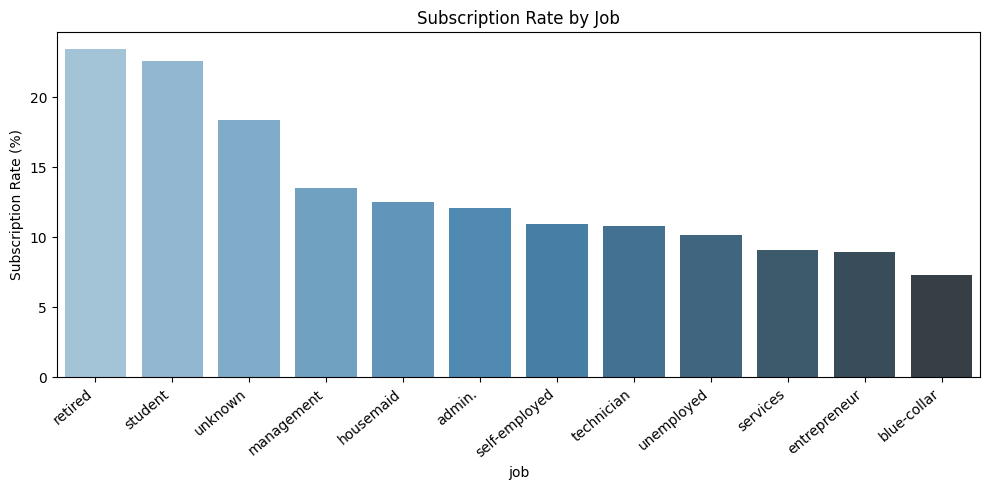

In [ ]:
job_pdf = df_spark.groupBy("job","y").count().toPandas()
job_rate = job_pdf[job_pdf["y"]=="yes"].copy()
totals = job_pdf.groupby("job")["count"].sum().reset_index(name="total")
job_rate = job_rate.merge(totals, on="job")
job_rate["rate"] = job_rate["count"] * 100 / job_rate["total"]
job_rate = job_rate.sort_values("rate", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=job_rate, x="job", y="rate", palette="Blues_d")
plt.xticks(rotation=40, ha="right")
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Job")
plt.tight_layout()
plt.savefig("eda_job_rate.png", dpi=120)
plt.show()

Call duration distribution:

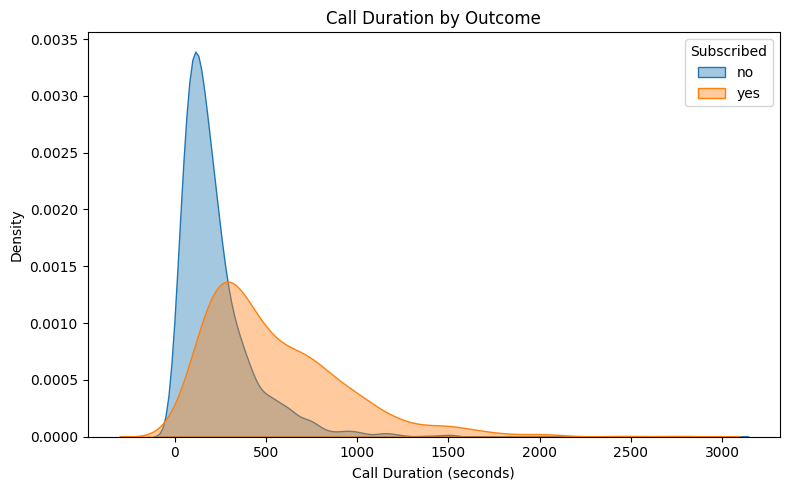

In [ ]:
plt.figure(figsize=(8,5))
for label, grp in pdf.groupby("y"):
    sns.kdeplot(grp["duration"], label=label, fill=True, alpha=0.4)
plt.xlabel("Call Duration (seconds)")
plt.title("Call Duration by Outcome")
plt.legend(title="Subscribed")
plt.tight_layout()
plt.savefig("eda_duration.png", dpi=120)
plt.show()

# Machine Learning

 Imports and setup:

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

df_ml = df_spark.withColumn("label", F.when(F.col("y")=="yes",1).otherwise(0))
df_ml = df_ml.withColumn("contacted_before", F.when(F.col("pdays")==-1,0).otherwise(1))

 Build pipeline:

In [ ]:
cat_cols = ["job","marital","education","default","housing","loan","contact","month","poutcome"]
num_cols_ml = ["age","balance","day","duration","campaign","pdays","previous","contacted_before"]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_enc") for c in cat_cols]
enc_cols = [f"{c}_enc" for c in cat_cols]

assembler = VectorAssembler(inputCols=num_cols_ml+enc_cols, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=False, withStd=True)

train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count()}  Test: {test_df.count()}")

Train: 3662  Test: 859


Logistic Regression:

In [ ]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100, regParam=0.01)
lr_pipeline = Pipeline(stages=indexers+encoders+[assembler, scaler, lr])
lr_model = lr_pipeline.fit(train_df)
lr_preds = lr_model.transform(test_df)

binary_eval = BinaryClassificationEvaluator(labelCol="label")
mc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

print("--- Logistic Regression ---")
print(f"AUC-ROC : {binary_eval.evaluate(lr_preds):.4f}")
print(f"Accuracy: {mc_eval.setMetricName('accuracy').evaluate(lr_preds):.4f}")
print(f"F1 Score: {mc_eval.setMetricName('f1').evaluate(lr_preds):.4f}")

--- Logistic Regression ---
AUC-ROC : 0.8813
Accuracy: 0.8941
F1 Score: 0.8765


 Random Forest:

In [ ]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, maxDepth=8, seed=42)
rf_pipeline = Pipeline(stages=indexers+encoders+[assembler, scaler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_preds = rf_model.transform(test_df)

print("--- Random Forest ---")
print(f"AUC-ROC : {binary_eval.evaluate(rf_preds):.4f}")
print(f"Accuracy: {mc_eval.setMetricName('accuracy').evaluate(rf_preds):.4f}")
print(f"F1 Score: {mc_eval.setMetricName('f1').evaluate(rf_preds):.4f}")

--- Random Forest ---
AUC-ROC : 0.9051
Accuracy: 0.8929
F1 Score: 0.8607


Feature importance chart:

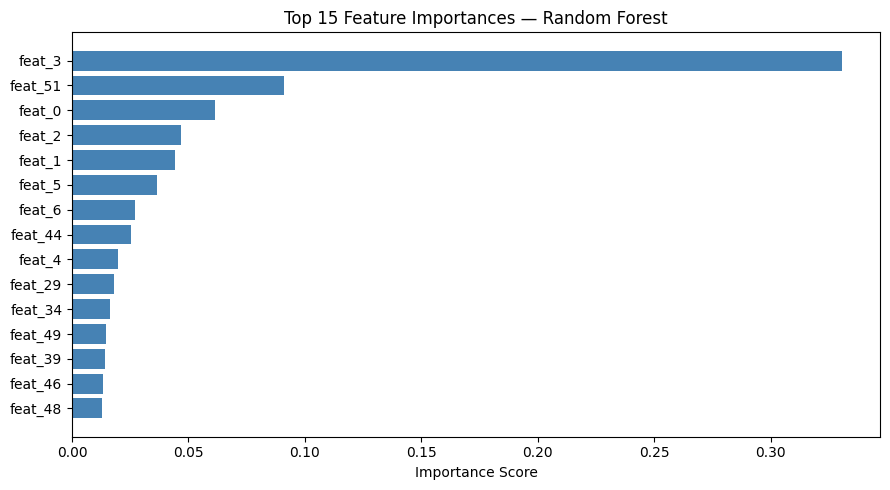

In [ ]:
importances = rf_model.stages[-1].featureImportances.toArray()
top_idx = importances.argsort()[::-1][:15]

plt.figure(figsize=(9,5))
plt.barh([f"feat_{i}" for i in top_idx[::-1]], importances[top_idx[::-1]], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=120)
plt.show()

# Streaming

In [ ]:
import time
import random

pdf_stream = df_spark.toPandas()

print("Simulating real-time stream — processing 5 batches...\n")

for batch_num in range(1, 6):
    # grab a random chunk of 100 rows as a "stream batch"
    batch = pdf_stream.sample(n=100, random_state=batch_num)

    subscribed = (batch["y"] == "yes").sum()
    avg_duration = batch["duration"].mean()
    high_value = (batch["duration"] > 400).sum()

    print(f"--- Batch {batch_num} (window {batch_num*15}s) ---")
    print(f"  Contacts     : {len(batch)}")
    print(f"  Subscribed   : {subscribed} ({subscribed}%)")
    print(f"  Avg Duration : {avg_duration:.1f} sec")
    print(f"  High-Value   : {high_value} calls (duration > 400s)")
    print()
    time.sleep(1)

print("Stream simulation complete.")

Simulating real-time stream — processing 5 batches...

--- Batch 1 (window 15s) ---
  Contacts     : 100
  Subscribed   : 17 (17%)
  Avg Duration : 267.9 sec
  High-Value   : 22 calls (duration > 400s)

--- Batch 2 (window 30s) ---
  Contacts     : 100
  Subscribed   : 10 (10%)
  Avg Duration : 232.4 sec
  High-Value   : 16 calls (duration > 400s)

--- Batch 3 (window 45s) ---
  Contacts     : 100
  Subscribed   : 10 (10%)
  Avg Duration : 258.5 sec
  High-Value   : 16 calls (duration > 400s)

--- Batch 4 (window 60s) ---
  Contacts     : 100
  Subscribed   : 11 (11%)
  Avg Duration : 273.6 sec
  High-Value   : 17 calls (duration > 400s)

--- Batch 5 (window 75s) ---
  Contacts     : 100
  Subscribed   : 11 (11%)
  Avg Duration : 269.5 sec
  High-Value   : 20 calls (duration > 400s)

Stream simulation complete.


Windowed aggregation by job:

In [ ]:
spark_stream_df = spark.createDataFrame(pdf_stream.sample(n=500, random_state=99))

print("--- Live window: subscription count by job ---")
spark_stream_df.groupBy("job","y").count().orderBy("count", ascending=False).show()

print("--- Flagged high-value contacts (duration > 400s) ---")
spark_stream_df.filter(F.col("duration") > 400) \
    .select("job","balance","duration","y") \
    .show(10)

--- Live window: subscription count by job ---
+-------------+---+-----+
|          job|  y|count|
+-------------+---+-----+
|   management| no|   91|
|  blue-collar| no|   91|
|   technician| no|   83|
|       admin.| no|   45|
|     services| no|   45|
|      retired| no|   20|
|   management|yes|   17|
| entrepreneur| no|   15|
|self-employed| no|   14|
|  blue-collar|yes|   13|
|      retired|yes|   11|
|   unemployed| no|   11|
|    housemaid| no|   11|
|      student| no|    7|
|       admin.|yes|    7|
|   technician|yes|    6|
|      unknown| no|    3|
|     services|yes|    3|
|      student|yes|    3|
| entrepreneur|yes|    2|
+-------------+---+-----+
only showing top 20 rows
--- Flagged high-value contacts (duration > 400s) ---
+-----------+-------+--------+---+
|        job|balance|duration|  y|
+-----------+-------+--------+---+
| management|    221|     720| no|
|     admin.|    305|     633|yes|
| management|    773|     618| no|
| technician|   -298|     559| no|
|    

# Data Parallelism

Repartitioning:

In [ ]:
import time

print(f"Default partitions: {df_spark.rdd.getNumPartitions()}")

df_hash = df_spark.repartition(8, "job")
df_range = df_spark.repartitionByRange(8, "age")

print(f"Hash partitions : {df_hash.rdd.getNumPartitions()}")
print(f"Range partitions: {df_range.rdd.getNumPartitions()}")

sizes = df_hash.rdd \
    .mapPartitionsWithIndex(lambda i, it: [(i, sum(1 for _ in it))]) \
    .collect()

print("\nPartition distribution (hash by job):")
for idx, sz in sorted(sizes):
    print(f"  Partition {idx}: {sz} rows")

Default partitions: 1
Hash partitions : 8
Range partitions: 8

Partition distribution (hash by job):
  Partition 0: 0 rows
  Partition 1: 1447 rows
  Partition 2: 0 rows
  Partition 3: 230 rows
  Partition 4: 667 rows
  Partition 5: 1129 rows
  Partition 6: 880 rows
  Partition 7: 168 rows


Risk score UDF:

In [ ]:
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf

@udf(DoubleType())
def risk_score(balance, campaign, pdays, previous, poutcome):
    score = 0.0
    if balance < 0:      score += 30
    if campaign > 5:     score += 20
    if pdays == -1:      score += 15
    if previous == 0:    score += 10
    if poutcome in ("failure","unknown"): score += 25
    return round(score, 2)

df_scored = df_spark.withColumn("risk_score",
    risk_score(F.col("balance"), F.col("campaign"),
               F.col("pdays"), F.col("previous"), F.col("poutcome")))

df_scored.select("risk_score").describe().show()

+-------+-----------------+
|summary|       risk_score|
+-------+-----------------+
|  count|             4521|
|   mean|48.20614908206149|
| stddev| 18.3163080114846|
|    min|              0.0|
|    max|            100.0|
+-------+-----------------+



Spark vs Pandas timing:

In [ ]:
import pandas as pd

# Spark
t0 = time.time()
for _ in range(3):
    df_spark.groupBy("job").agg(F.avg("balance"), F.avg("duration")).collect()
spark_time = (time.time()-t0)/3

# Pandas
pdf2 = pd.read_csv('/content/drive/MyDrive/Assignment_doc/distributed-banking-ml/data/bank.csv')
t0 = time.time()
for _ in range(3):
    pdf2.groupby("job")[["balance","duration"]].mean()
pandas_time = (time.time()-t0)/3

print(f"Spark avg  : {spark_time:.3f}s")
print(f"Pandas avg : {pandas_time:.3f}s")
print(f"Note: Spark overhead visible at small scale — advantage appears at millions of rows")

Spark avg  : 0.247s
Pandas avg : 0.002s
Note: Spark overhead visible at small scale — advantage appears at millions of rows


Partition chart:

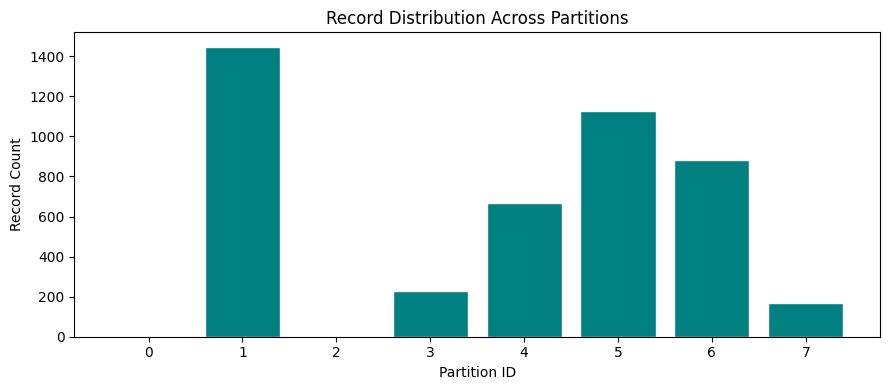

In [ ]:
parts, counts = zip(*sorted(sizes))
plt.figure(figsize=(9,4))
plt.bar(parts, counts, color="teal", edgecolor="white")
plt.xlabel("Partition ID")
plt.ylabel("Record Count")
plt.title("Record Distribution Across Partitions")
plt.tight_layout()
plt.savefig("partition_distribution.png", dpi=120)
plt.show()

# Download all charts

In [ ]:
from google.colab import files

for fname in ["eda_correlation.png", "eda_job_rate.png", "eda_duration.png",
              "feature_importances.png", "partition_distribution.png"]:
    files.download(f"/content/drive/MyDrive/Assignment_doc/distributed-banking-ml/{fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>